In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('courses.csv')
df

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,...,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,...,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641133,641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,...,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,NaN
641134,641134,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,...,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,NaN
641135,641135,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,...,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,NaN
641136,641136,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,...,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  str    
 2   userid_DI          641138 non-null  str    
 3   registered         641138 non-null  int64  
 4   viewed             641138 non-null  int64  
 5   explored           641138 non-null  int64  
 6   certified          641138 non-null  int64  
 7   final_cc_cname_DI  641138 non-null  str    
 8   LoE_DI             535130 non-null  str    
 9   YoB                544533 non-null  float64
 10  gender             554332 non-null  str    
 11  grade              592766 non-null  str    
 12  start_time_DI      641138 non-null  str    
 13  last_event_DI      462184 non-null  str    
 14  nevents            441987 non-null  float64
 15  ndays_act          478395 non-null  float64
 16  nplay_video  

In [15]:
df.isna().sum()

index                     0
course_id                 0
userid_DI                 0
registered                0
viewed                    0
explored                  0
certified                 0
final_cc_cname_DI         0
LoE_DI               106008
YoB                   96605
gender                86806
grade                 48372
start_time_DI             0
last_event_DI        178954
nevents              199151
ndays_act            162743
nplay_video          457530
nchapters            258753
nforum_posts              0
roles                641138
incomplete_flag      540977
dtype: int64

In [17]:
df['LoE_DI'].value_counts(dropna=False)

LoE_DI
Bachelor's             219768
Secondary              169694
Master's               118189
NaN                    106008
Less than Secondary     14092
Doctorate               13387
Name: count, dtype: int64

In [18]:
df['YoB'].value_counts(dropna=False)

YoB
NaN       96605
1990.0    38524
1992.0    37846
1991.0    37544
1989.0    36831
          ...  
2003.0       10
2009.0        8
1931.0        7
2007.0        6
1934.0        5
Name: count, Length: 79, dtype: int64

In [19]:
df['age'] = 2013 - df['YoB']
df[['YoB', 'age']]

,YoB,age
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
641133,1991.0,22.0
641134,1991.0,22.0
641135,1979.0,34.0
641136,1979.0,34.0


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('courses.csv')

# 필요 없는 컬럼 삭제
df = df.drop(columns=['roles', 'index'])

# 인적사항 결측치 unknown (나이는 밑에서 따로)
df['gender'] = df['gender'].fillna('unknown')
df['gender'] = df['gender'].replace(['o'], 'unknown')
df['LoE_DI'] = df['LoE_DI'].fillna('unknown')

# 나이대 구하기
import datetime

df['age'] = 2013 - df['YoB']

# 나이 함수 정의
def ages(age):
    if pd.isna(age):
        return 'unknown'
    elif age < 10:
        return '0~9'
    elif age < 20:
        return '10s'
    elif age < 30:
        return '20s'
    elif age < 40:
        return '30s'
    elif age < 50:
        return '40s'
    elif age < 60:
        return '50s'
    else:
        return '60s up'

df['age_group'] = df['age'].apply(ages)

# 성적 결측치 0 처리
df['grade'] = pd.to_numeric(df['grade'], errors='coerce').fillna(0)

# 날짜 변환 및 학습 기간 생성
df['start_time_DI'] = pd.to_datetime(df['start_time_DI'])
df['last_event_DI'] = pd.to_datetime(df['last_event_DI']).fillna(df['start_time_DI'])
df['learning_duration'] = (df['last_event_DI'] - df['start_time_DI']).dt.days

# 활동 관련 컬럼 결측치 채우기
activity_cols = ['nevents', 'ndays_act', 'nplay_video', 'nchapters']
df[activity_cols] = df[activity_cols].fillna(0)

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_group,learning_duration
1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,unknown,NaN,unknown,...,2012-10-15,NaN,9.0,NaN,1.0,0,1.0,NaN,unknown,0
3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,unknown,NaN,unknown,...,2012-09-17,NaN,16.0,NaN,NaN,0,1.0,NaN,unknown,0
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,unknown,NaN,unknown,...,2012-12-19,NaN,16.0,NaN,NaN,0,1.0,NaN,unknown,0
6,HarvardX/PH278x/2013_Spring,MHxPC130275857,1,0,0,0,United States,unknown,NaN,unknown,...,2013-02-08,NaN,16.0,NaN,NaN,0,1.0,NaN,unknown,0
9,HarvardX/CS50x/2012,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2012-10-20,NaN,12.0,NaN,3.0,0,1.0,NaN,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,...,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,22.0,20s,0
641134,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,...,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,22.0,20s,0
641135,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,...,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,34.0,30s,0
641136,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,...,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,34.0,30s,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   course_id          641138 non-null  str    
 1   userid_DI          641138 non-null  str    
 2   registered         641138 non-null  int64  
 3   viewed             641138 non-null  int64  
 4   explored           641138 non-null  int64  
 5   certified          641138 non-null  int64  
 6   final_cc_cname_DI  641138 non-null  str    
 7   LoE_DI             641138 non-null  str    
 8   YoB                544533 non-null  float64
 9   gender             641138 non-null  str    
 10  grade              592766 non-null  str    
 11  start_time_DI      641138 non-null  str    
 12  last_event_DI      462184 non-null  str    
 13  nevents            441987 non-null  float64
 14  ndays_act          478395 non-null  float64
 15  nplay_video        183608 non-null  float64
 16  nchapters    

In [22]:
df.isna().sum()

course_id                 0
userid_DI                 0
registered                0
viewed                    0
explored                  0
certified                 0
final_cc_cname_DI         0
LoE_DI                    0
YoB                   96605
gender                    0
grade                 48372
start_time_DI             0
last_event_DI        178954
nevents              199151
ndays_act            162743
nplay_video          457530
nchapters            258753
nforum_posts              0
incomplete_flag      540977
age                   96605
age_group                 0
dtype: int64

In [29]:
df['nevents'].value_counts(dropna=False)

nevents
NaN        199151
1.0         63565
2.0         34329
3.0         17669
4.0         12217
            ...  
11676.0         1
7123.0          1
8488.0          1
5208.0          1
11091.0         1
Name: count, Length: 10610, dtype: int64

In [32]:
df['ndays_act'].describe()

count    478395.000000
mean          5.710254
std          11.866471
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         205.000000
Name: ndays_act, dtype: float64

In [ ]:
display(df[df['certified'] == 1]['nevents'].describe())
display(df[df['certified'] == 0]['nevents'].describe())

count    17675.000000
mean      5163.269024
std       4158.441222
min          4.000000
25%       1830.000000
50%       4513.000000
75%       7335.000000
max      61376.000000
Name: nevents, dtype: float64

count    424312.000000
mean        233.882523
std         838.063828
min           1.000000
25%           3.000000
50%          21.000000
75%         125.000000
max      197757.000000
Name: nevents, dtype: float64

In [57]:
df[df['nevents'] == 197757]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_group,learning_duration
353229,MITx/6.00x/2012_Fall,MHxPC130155963,1,1,0,0,Other South America,unknown,NaN,unknown,...,2012-12-19,197757.0,19.0,98517.0,5.0,0,NaN,NaN,unknown,110


In [37]:
display(df[df['certified'] == 1]['nplay_video'].describe())
display(df[df['certified'] == 0]['nplay_video'].describe())

count    13306.000000
mean       663.372013
std        860.513237
min          1.000000
25%        155.000000
50%        418.000000
75%        856.000000
max      19179.000000
Name: nplay_video, dtype: float64

count    170302.000000
mean         71.986712
std         336.712327
min           1.000000
25%           4.000000
50%          16.000000
75%          55.000000
max       98517.000000
Name: nplay_video, dtype: float64

In [44]:
display(df[df['certified'] == 1]['nchapters'].describe())
display(df[df['certified'] == 0]['nchapters'].describe())

count    17687.000000
mean        16.714310
std          6.542027
min          1.000000
25%         12.000000
50%         16.000000
75%         18.000000
max         48.000000
Name: nchapters, dtype: float64

count    364698.000000
mean          3.000080
std           3.220567
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          48.000000
Name: nchapters, dtype: float64

In [45]:
display(df[df['certified'] == 1]['nforum_posts'].describe())
display(df[df['certified'] == 0]['nforum_posts'].describe())

count    17687.000000
mean         0.211229
std          0.903549
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         20.000000
Name: nforum_posts, dtype: float64

count    623451.000000
mean          0.013513
std           0.173046
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          13.000000
Name: nforum_posts, dtype: float64

In [42]:
df[(df['viewed'] == 1)&(df['nplay_video'] >= 600)]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_group,learning_duration
90,HarvardX/PH207x/2012_Fall,MHxPC130172433,1,1,0,0,United States,unknown,NaN,unknown,...,2012-11-19,2796.0,23.0,891.0,6.0,0,NaN,NaN,unknown,33
444,HarvardX/PH207x/2012_Fall,MHxPC130389796,1,1,1,0,United States,unknown,NaN,unknown,...,2012-12-31,4768.0,55.0,1008.0,11.0,0,NaN,NaN,unknown,130
460,HarvardX/PH207x/2012_Fall,MHxPC130183354,1,1,1,1,United Kingdom,unknown,NaN,unknown,...,2013-01-20,11886.0,83.0,1785.0,16.0,1,NaN,NaN,unknown,150
1682,HarvardX/PH207x/2012_Fall,MHxPC130479701,1,1,1,1,United Kingdom,unknown,NaN,unknown,...,2013-01-19,6528.0,62.0,875.0,16.0,0,NaN,NaN,unknown,97
2242,HarvardX/PH207x/2012_Fall,MHxPC130024795,1,1,1,1,Other South Asia,unknown,NaN,unknown,...,2013-04-23,8066.0,32.0,917.0,15.0,0,NaN,NaN,unknown,198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634982,MITx/6.002x/2013_Spring,MHxPC130448038,1,1,0,0,United States,Bachelor's,1961.0,m,...,2013-09-01,3564.0,18.0,762.0,6.0,0,NaN,52.0,50s,22
635447,MITx/6.002x/2013_Spring,MHxPC130018748,1,1,1,0,Russian Federation,Secondary,1993.0,m,...,2013-08-24,10495.0,7.0,3741.0,13.0,0,NaN,20.0,20s,11
635917,MITx/6.002x/2013_Spring,MHxPC130037154,1,1,1,0,Other Europe,Master's,1978.0,m,...,2013-08-27,7934.0,5.0,2732.0,14.0,0,NaN,35.0,30s,12
637649,MITx/6.00x/2013_Spring,MHxPC130071865,1,1,1,0,United States,Doctorate,1982.0,f,...,2013-08-26,2258.0,3.0,1068.0,16.0,0,NaN,31.0,30s,3


In [33]:
df[df['certified'] == 1]['ndays_act'].describe()

count    17675.000000
mean        46.910778
std         26.405434
min          1.000000
25%         26.000000
50%         43.000000
75%         64.000000
max        162.000000
Name: ndays_act, dtype: float64

In [34]:
df[df['certified'] == 0]['ndays_act'].describe()

count    460720.000000
mean          4.129643
std           7.200497
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         205.000000
Name: ndays_act, dtype: float64

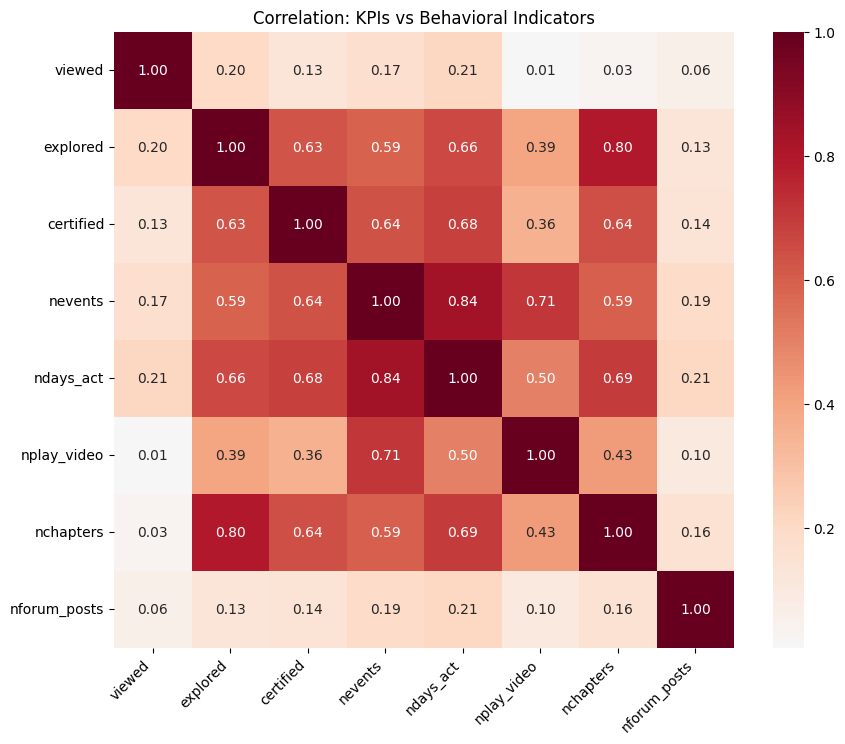

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석할 컬럼 정의
kpis = ['viewed', 'explored', 'certified']
behaviors = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']

# 1. 상관계수 계산 (Pearson correlation)
# KPI와 행동 지표 간의 관계만 추출합니다.
corr_matrix = df[kpis + behaviors].corr()

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation: KPIs vs Behavioral Indicators')

# x축 라벨 45도 회전 및 우측 정렬
plt.xticks(rotation=45, ha='right')
# (선택사항) y축 라벨도 읽기 편하게 0도로 고정하고 싶다면:
plt.yticks(rotation=0)

plt.show()

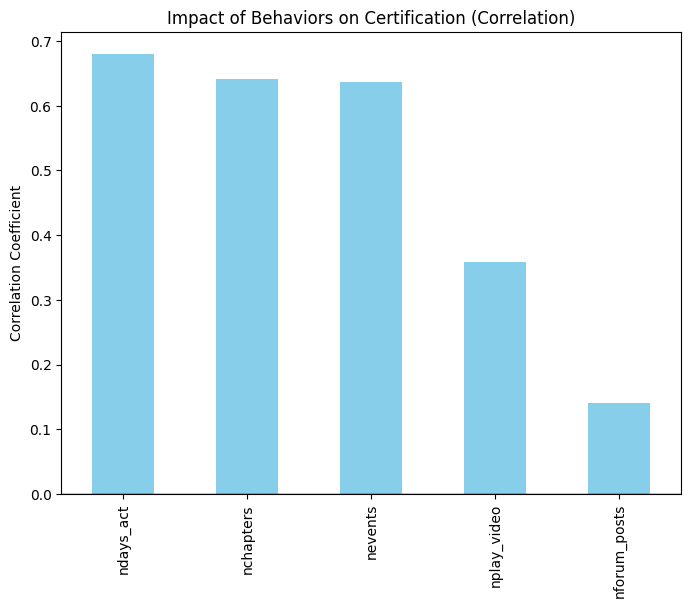

In [47]:
# 'certified'와 행동 지표들 간의 상관관계만 추출하여 정렬
certified_influence = corr_matrix.loc[behaviors, 'certified'].sort_values(ascending=False)

# 막대 그래프로 시각화
plt.figure(figsize=(8, 6))
certified_influence.plot(kind='bar', color='skyblue')
plt.axhline(0, color='black', linewidth=1) # 기준선
plt.title('Impact of Behaviors on Certification (Correlation)')
plt.ylabel('Correlation Coefficient')
plt.show()

In [50]:
# 상관계수 행렬 계산
corr = df[behaviors].corr()

# 자기 자신(1.0)을 제외하고 상관관계가 높은 쌍 찾기
high_corr = corr.unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1].drop_duplicates()

print("상관계수가 높은 변수 쌍 (0.8 이상 주의):")
print(high_corr[high_corr > 0.8])

상관계수가 높은 변수 쌍 (0.8 이상 주의):
ndays_act  nevents    0.835387
dtype: float64


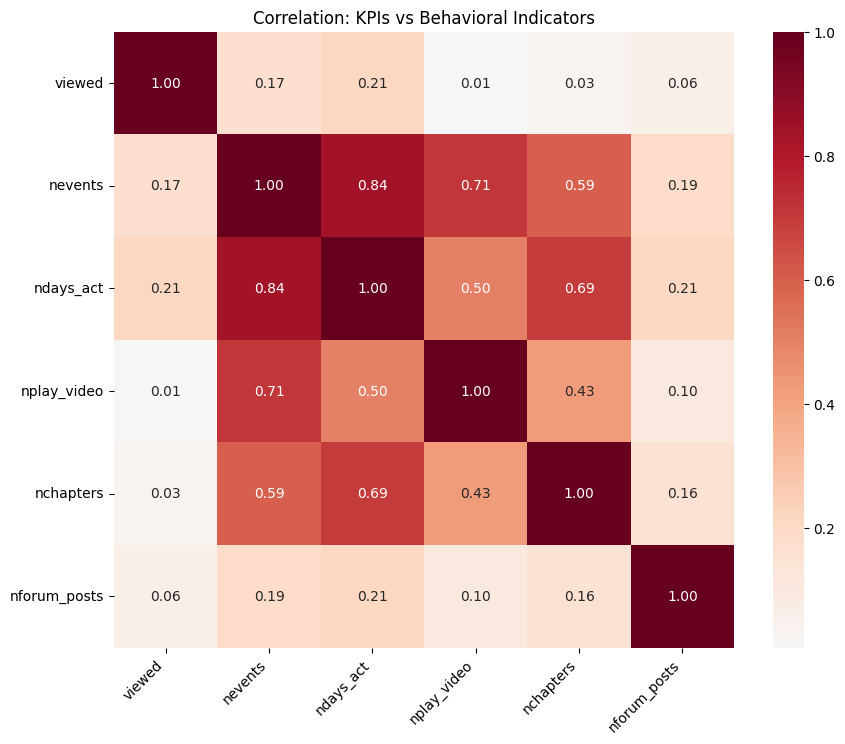

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석할 컬럼 정의
kpis = ['viewed']
behaviors = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']

# 1. 상관계수 계산 (Pearson correlation)
# KPI와 행동 지표 간의 관계만 추출합니다.
corr_matrix = df[kpis + behaviors].corr()

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation: KPIs vs Behavioral Indicators')

# x축 라벨 45도 회전 및 우측 정렬
plt.xticks(rotation=45, ha='right')
# (선택사항) y축 라벨도 읽기 편하게 0도로 고정하고 싶다면:
plt.yticks(rotation=0)

plt.show()

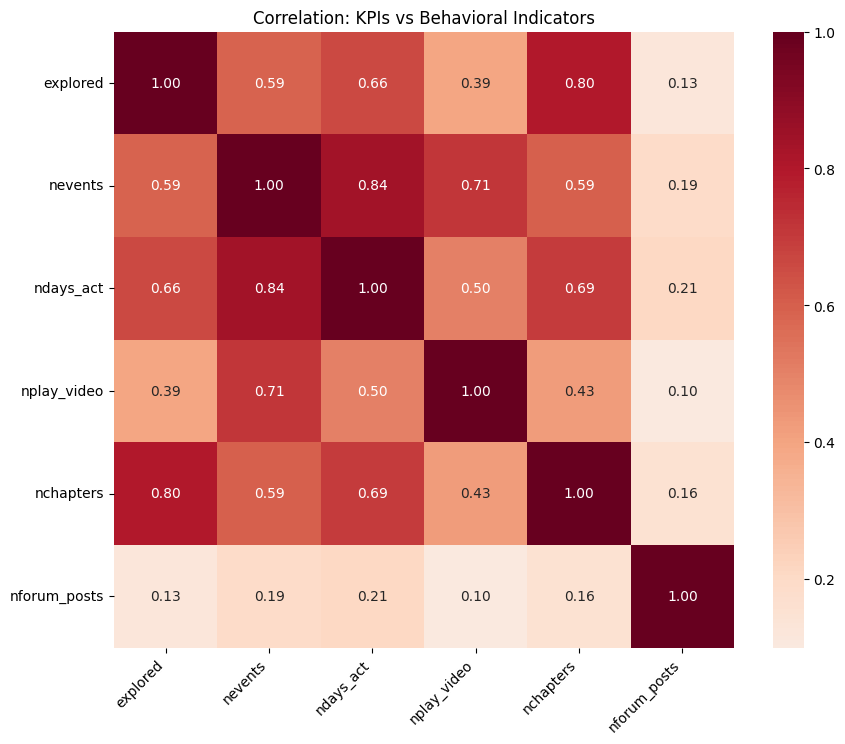

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석할 컬럼 정의
kpis = ['explored']
behaviors = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']

# 1. 상관계수 계산 (Pearson correlation)
# KPI와 행동 지표 간의 관계만 추출합니다.
corr_matrix = df[kpis + behaviors].corr()

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation: KPIs vs Behavioral Indicators')

# x축 라벨 45도 회전 및 우측 정렬
plt.xticks(rotation=45, ha='right')
# (선택사항) y축 라벨도 읽기 편하게 0도로 고정하고 싶다면:
plt.yticks(rotation=0)

plt.show()

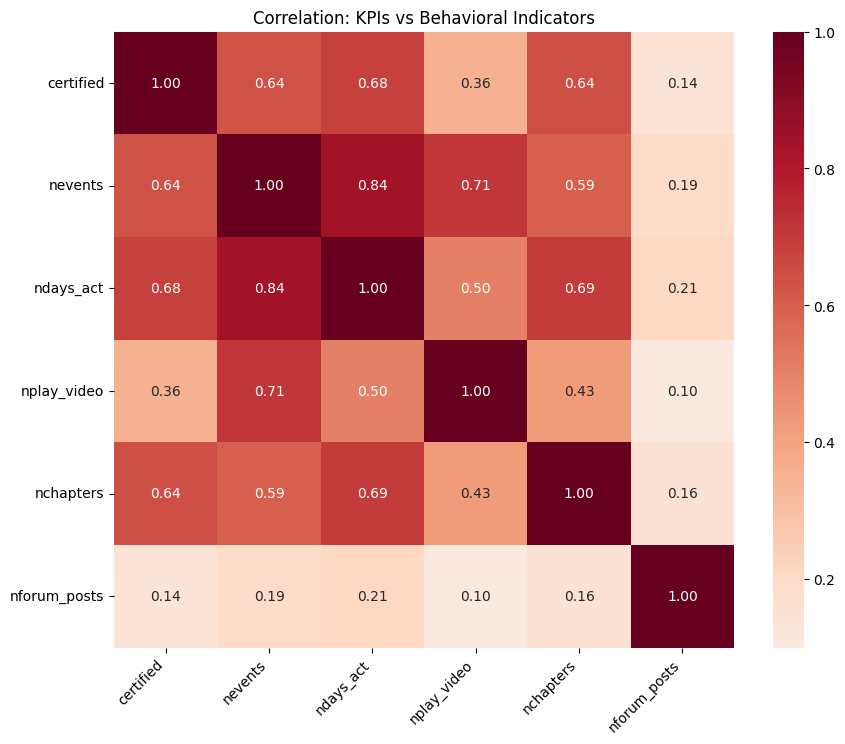

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석할 컬럼 정의
kpis = ['certified']
behaviors = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']

# 1. 상관계수 계산 (Pearson correlation)
# KPI와 행동 지표 간의 관계만 추출합니다.
corr_matrix = df[kpis + behaviors].corr()

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation: KPIs vs Behavioral Indicators')

# x축 라벨 45도 회전 및 우측 정렬
plt.xticks(rotation=45, ha='right')
# (선택사항) y축 라벨도 읽기 편하게 0도로 고정하고 싶다면:
plt.yticks(rotation=0)

plt.show()

In [55]:
df[(df['learning_duration'] == 0)&(df['certified']==1)]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_group,learning_duration
7291,HarvardX/ER22x/2013_Spring,MHxPC130346293,1,1,0,1,India,unknown,NaN,unknown,...,2013-05-29,120.0,1.0,NaN,3.0,0,NaN,NaN,unknown,0
83309,HarvardX/ER22x/2013_Spring,MHxPC130545959,1,1,0,1,India,Bachelor's,1993.0,m,...,2013-07-17,132.0,1.0,NaN,2.0,0,NaN,20.0,20s,0
83828,HarvardX/ER22x/2013_Spring,MHxPC130452251,1,1,0,1,Canada,Bachelor's,1988.0,m,...,2013-07-22,384.0,1.0,NaN,7.0,0,NaN,25.0,20s,0
92500,HarvardX/CB22x/2013_Spring,MHxPC130313264,1,1,1,1,Ukraine,Secondary,1993.0,m,...,2013-07-14,1445.0,1.0,NaN,24.0,0,NaN,20.0,20s,0
106843,HarvardX/CS50x/2012,MHxPC130306856,1,1,1,1,Unknown/Other,Doctorate,1968.0,m,...,2012-11-30,NaN,NaN,NaN,12.0,0,1.0,45.0,40s,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462248,MITx/6.00x/2012_Fall,MHxPC130383454,1,1,1,1,Unknown/Other,Secondary,1993.0,m,...,2012-10-01,NaN,NaN,NaN,9.0,0,1.0,20.0,20s,0
514799,MITx/6.002x/2013_Spring,MHxPC130276145,1,1,1,1,India,Secondary,1992.0,m,...,2012-12-27,NaN,NaN,NaN,17.0,1,1.0,21.0,20s,0
547604,MITx/7.00x/2013_Spring,MHxPC130043740,1,1,1,1,Unknown/Other,Bachelor's,1989.0,f,...,2013-03-12,NaN,NaN,NaN,13.0,0,1.0,24.0,20s,0
555757,MITx/7.00x/2013_Spring,MHxPC130074389,1,1,1,1,Unknown/Other,Master's,1986.0,f,...,2013-03-12,NaN,NaN,NaN,16.0,0,1.0,27.0,20s,0


In [58]:
df[(df['last_event_DI'].isna())&(df['certified']==1)]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_group,learning_duration


In [60]:
df[df['last_event_DI'].isna()]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_group,learning_duration


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('courses.csv')
df

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,...,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,...,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641133,641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,...,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,NaN
641134,641134,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,...,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,NaN
641135,641135,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,...,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,NaN
641136,641136,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,...,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,NaN


In [23]:
cond1 = (df['explored'] == 0)&(df['certified'] == 1)
cond2 = (df['viewed'] == 0)&(df['explored'] == 1)
df_c = df[cond1 | cond2]
df_c[df_c['grade'] == 0]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,log1p_ndays_act,log1p_nplay_video,log1p_nchapters,log1p_nforum_posts,q_grade,q_log1p_nevents,q_log1p_ndays_act,q_log1p_nplay_video,q_log1p_nchapters,q_log1p_nforum_posts
232732,232732,HarvardX/PH207x/2012_Fall,MHxPC130066792,1,1,0,1,United States,NaN,NaN,...,0.693147,0.0,1.791759,0.0,0.442022,0.734892,0.417561,0.356812,0.896574,0.494182
365180,365180,MITx/6.002x/2012_Fall,MHxPC130007852,1,0,1,0,Other Middle East/Central Asia,NaN,NaN,...,1.098612,0.0,2.890372,0.0,0.442022,0.574065,0.644162,0.356812,0.984761,0.494182
370050,370050,MITx/6.002x/2012_Fall,MHxPC130167688,1,0,1,0,United States,NaN,NaN,...,0.693147,0.0,2.890372,0.0,0.442022,0.436538,0.417561,0.356812,0.984761,0.494182
571332,571332,MITx/8.02x/2013_Spring,MHxPC130562889,1,0,1,0,China,NaN,NaN,...,0.693147,0.0,2.397895,0.0,0.442022,0.360194,0.417561,0.356812,0.947904,0.494182
626905,626905,MITx/8.02x/2013_Spring,MHxPC130501631,1,0,1,0,Canada,Secondary,1993.0,...,0.693147,0.0,2.833213,0.0,0.442022,0.155311,0.417561,0.356812,0.981044,0.494182
630822,630822,MITx/8.02x/2013_Spring,MHxPC130414770,1,0,1,0,United States,Secondary,1996.0,...,0.693147,0.0,2.484907,0.0,0.442022,0.360194,0.417561,0.356812,0.953251,0.494182
631023,631023,MITx/6.002x/2013_Spring,MHxPC130426148,1,0,1,0,Other South Asia,Secondary,1995.0,...,1.098612,0.0,2.833213,0.0,0.442022,0.676516,0.644162,0.356812,0.981044,0.494182
635912,635912,MITx/6.00x/2013_Spring,MHxPC130585243,1,0,1,0,United States,Bachelor's,1989.0,...,0.693147,0.0,2.890372,0.0,0.442022,0.436538,0.417561,0.356812,0.984761,0.494182
636492,636492,MITx/6.00x/2013_Spring,MHxPC130541801,1,0,1,0,United States,Bachelor's,1980.0,...,0.000000,0.0,2.890372,0.0,0.442022,0.155311,0.126918,0.356812,0.984761,0.494182


In [10]:
df_test = df_c[['viewed', 'explored', 'certified', 'LoE_DI', 'grade', 'start_time_DI', 'last_event_DI', 
      'nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']]

In [11]:
df_test[df_test['viewed'] == 0]

,viewed,explored,certified,LoE_DI,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts
365180,0,1,0,NaN,0,2012-09-30,2013-01-07,10.0,2.0,NaN,17.0,0
370050,0,1,0,NaN,0,2012-11-03,2012-11-04,2.0,1.0,NaN,17.0,0
571332,0,1,0,NaN,0,2013-02-21,2013-02-21,1.0,1.0,NaN,10.0,0
626905,0,1,0,Secondary,0,2013-06-12,NaN,NaN,1.0,NaN,16.0,0
630822,0,1,0,Secondary,NaN,2013-08-26,2013-08-26,1.0,1.0,NaN,11.0,0
631023,0,1,0,Secondary,NaN,2013-07-23,2013-07-27,30.0,2.0,NaN,16.0,0
635912,0,1,0,Bachelor's,NaN,2013-08-15,2013-08-15,2.0,1.0,NaN,17.0,0
636492,0,1,0,Bachelor's,NaN,2013-08-18,NaN,NaN,NaN,NaN,17.0,0


In [15]:
df_test[(df_test['explored'] == 0)&(df_test['grade'] <= '0.5')]

,viewed,explored,certified,LoE_DI,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts
204640,1,0,1,Bachelor's,0.5,2013-01-02,2013-08-26,1779.0,11.0,289.0,5.0,0
204641,1,0,1,Bachelor's,0.5,2013-01-02,2013-06-24,1310.0,21.0,158.0,5.0,0
232732,1,0,1,NaN,0,2013-02-01,2013-03-03,56.0,1.0,NaN,5.0,0
272140,1,0,1,Bachelor's,0.5,2013-03-12,2013-06-27,1301.0,7.0,86.0,5.0,0
284001,1,0,1,Secondary,0.5,2013-03-30,2013-05-29,644.0,5.0,28.0,4.0,0
294083,1,0,1,Bachelor's,0.5,2013-04-23,2013-08-22,794.0,6.0,85.0,5.0,0
512903,1,0,1,NaN,0.5,2012-12-23,2013-03-19,2260.0,15.0,280.0,5.0,0
542638,1,0,1,Master's,0.5,2013-01-30,2013-03-19,1878.0,12.0,165.0,5.0,0
590523,1,0,1,Secondary,0.5,2013-03-14,2013-06-24,661.0,8.0,40.0,10.0,0


In [18]:
import numpy as np
import pandas as pd

# 성적 결측치 0 처리
df['grade'] = pd.to_numeric(df['grade'], errors='coerce').fillna(0)

BEHAV = ["nevents", "ndays_act", "nplay_video", "nchapters", "nforum_posts"]  # 컬럼명 맞게 수정
# 예: n_play_video라면 "n_play_video"로 바꿔줘

# 1) 그룹 만들기
df["group"] = np.select(
    [
        (df["explored"]==0) & (df["certified"]==1),
        (df["explored"]==1) & (df["certified"]==1),
        (df["explored"]==0) & (df["certified"]==0),
        (df["explored"]==1) & (df["certified"]==0),
    ],
    ["A_e0c1", "B_e1c1", "C_e0c0", "D_e1c0"],
    default="other"
)

# 2) 로그 변환 (0 많은 변수 대응)
for c in BEHAV:
    df[f"log1p_{c}"] = np.log1p(df[c].fillna(0))

# 3) 분위수(0~1)로 표준화: 전체에서의 상대적 위치
# (동점 처리/결측 처리 단순화)
for c in ["grade"] + [f"log1p_{x}" for x in BEHAV]:
    df[f"q_{c}"] = df[c].fillna(0).rank(pct=True)

# 4) 집단별 요약: median/IQR + zero-rate
def summarize(col):
    x = col.dropna()
    return pd.Series({
        "n": len(x),
        "median": x.median(),
        "q25": x.quantile(0.25),
        "q75": x.quantile(0.75),
        "mean": x.mean()
    })

summary = {}
summary["grade"] = df.groupby("group")["grade"].apply(summarize).unstack()

for c in BEHAV:
    summary[f"{c}_zero_rate"] = df.groupby("group")[c].apply(lambda s: (s.fillna(0)==0).mean())
    summary[f"{c}_pos_median"] = df.groupby("group")[c].apply(lambda s: s[s.fillna(0)>0].median())

summary_df = pd.concat(
    [summary["grade"]] + [v.to_frame(name=k) if isinstance(v, pd.Series) else v for k,v in summary.items() if k!="grade"],
    axis=1
)

print(summary_df)

# 5) A집단 내부를 grade로 쪼개기
A = df[df["group"]=="A_e0c1"].copy()
T = 0.6  # 필요 시 조정

A["grade_band"] = pd.cut(
    A["grade"].fillna(0),
    bins=[-0.001, 0, T, 1.0],
    labels=["grade=0", "0<grade<T", "grade>=T"]
)

band_summary = A.groupby("grade_band")[["grade"] + BEHAV].agg(["count","median","mean"])
print(band_summary)

               n  median   q25   q75      mean  nevents_zero_rate  \
group                                                               
A_e0c1     690.0   0.805  0.65  0.95  0.794188           0.001449   
B_e1c1   16997.0   0.860  0.74  0.95  0.837294           0.000647   
C_e0c0  600762.0   0.000  0.00  0.00  0.004344           0.328088   
D_e1c0   22689.0   0.000  0.00  0.19  0.108200           0.089735   

        nevents_pos_median  ndays_act_zero_rate  ndays_act_pos_median  \
group                                                                   
A_e0c1               520.0             0.001449                   9.0   
B_e1c1              4703.0             0.000647                  45.0   
C_e0c0                18.0             0.267883                   2.0   
D_e1c0               731.0             0.079201                  14.0   

        nplay_video_zero_rate  nplay_video_pos_median  nchapters_zero_rate  \
group                                                               

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('courses.csv')
df['grade'] = pd.to_numeric(df['grade'], errors='coerce').fillna(0)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  str    
 2   userid_DI          641138 non-null  str    
 3   registered         641138 non-null  int64  
 4   viewed             641138 non-null  int64  
 5   explored           641138 non-null  int64  
 6   certified          641138 non-null  int64  
 7   final_cc_cname_DI  641138 non-null  str    
 8   LoE_DI             535130 non-null  str    
 9   YoB                544533 non-null  float64
 10  gender             554332 non-null  str    
 11  grade              641138 non-null  float64
 12  start_time_DI      641138 non-null  str    
 13  last_event_DI      462184 non-null  str    
 14  nevents            441987 non-null  float64
 15  ndays_act          478395 non-null  float64
 16  nplay_video  

In [2]:
df['course_id'].value_counts(dropna=False)

course_id
HarvardX/CS50x/2012            169621
MITx/6.00x/2012_Fall            66731
MITx/6.00x/2013_Spring          57715
HarvardX/ER22x/2013_Spring      57406
HarvardX/PH207x/2012_Fall       41592
MITx/6.002x/2012_Fall           40811
HarvardX/PH278x/2013_Spring     39602
MITx/8.02x/2013_Spring          31048
HarvardX/CB22x/2013_Spring      30002
MITx/14.73x/2013_Spring         27870
MITx/6.002x/2013_Spring         22235
MITx/7.00x/2013_Spring          21009
MITx/3.091x/2012_Fall           14215
MITx/8.MReV/2013_Summer          9477
MITx/3.091x/2013_Spring          6139
MITx/2.01x/2013_Spring           5665
Name: count, dtype: int64

In [3]:
df[df['course_id'] == 0]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag


In [4]:
df.head()

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,...,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,...,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0


In [5]:
df.loc[df['course_id']==0]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag


In [6]:
df[df['nplay_video'] == 0]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag


In [7]:
df['nplay_video'].value_counts(dropna=False)

nplay_video
NaN       457530
1.0        16968
2.0        11000
3.0         8371
4.0         6995
           ...  
2673.0         1
6317.0         1
2532.0         1
3741.0         1
2732.0         1
Name: count, Length: 2729, dtype: int64

In [8]:
df['nplay_video'].isna().sum()

np.int64(457530)

In [10]:
df.groupby('course_id')['nplay_video'].count()

course_id
HarvardX/CB22x/2013_Spring         0
HarvardX/CS50x/2012                0
HarvardX/ER22x/2013_Spring         0
HarvardX/PH207x/2012_Fall      20733
HarvardX/PH278x/2013_Spring    12544
MITx/14.73x/2013_Spring        12660
MITx/2.01x/2013_Spring          3115
MITx/3.091x/2012_Fall           5936
MITx/3.091x/2013_Spring         2784
MITx/6.002x/2012_Fall          19623
MITx/6.002x/2013_Spring         8891
MITx/6.00x/2012_Fall           36290
MITx/6.00x/2013_Spring         32950
MITx/7.00x/2013_Spring         10330
MITx/8.02x/2013_Spring         17236
MITx/8.MReV/2013_Summer          516
Name: nplay_video, dtype: int64

In [12]:
df[(df['grade'] == 0) & (df['certified'] == 1)]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag


In [13]:
df[df['grade'] == 1.01]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag


In [15]:
df.loc[df['grade']=='1.01']

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
68049,68049,HarvardX/PH207x/2012_Fall,MHxPC130274402,1,1,1,1,Germany,NaN,NaN,...,1.01,2012-08-26,2013-03-12,8175.0,91.0,562.0,16.0,0,NaN,NaN
121930,121930,HarvardX/PH207x/2012_Fall,MHxPC130025604,1,1,1,1,Other Europe,Master's,1987.0,...,1.01,2012-10-08,2013-05-03,14816.0,76.0,4670.0,15.0,0,NaN,NaN
136240,136240,HarvardX/PH207x/2012_Fall,MHxPC130424307,1,1,1,1,India,Master's,1987.0,...,1.01,2012-10-15,2013-05-06,6212.0,51.0,910.0,16.0,0,NaN,NaN
144904,144904,HarvardX/PH207x/2012_Fall,MHxPC130045969,1,1,1,1,Poland,Secondary,1988.0,...,1.01,2012-10-17,2013-03-27,9407.0,57.0,1731.0,14.0,0,NaN,NaN
151048,151048,HarvardX/PH207x/2012_Fall,MHxPC130154156,1,1,1,1,India,Master's,1984.0,...,1.01,2012-10-21,2013-07-06,11427.0,60.0,944.0,15.0,1,NaN,NaN
152799,152799,HarvardX/PH207x/2012_Fall,MHxPC130183123,1,1,1,1,Other Africa,Bachelor's,1988.0,...,1.01,2012-10-22,2013-01-16,3832.0,35.0,NaN,13.0,0,NaN,NaN


In [16]:
df['grade'] = pd.to_numeric(df['grade'], errors='coerce').fillna(0)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  str    
 2   userid_DI          641138 non-null  str    
 3   registered         641138 non-null  int64  
 4   viewed             641138 non-null  int64  
 5   explored           641138 non-null  int64  
 6   certified          641138 non-null  int64  
 7   final_cc_cname_DI  641138 non-null  str    
 8   LoE_DI             535130 non-null  str    
 9   YoB                544533 non-null  float64
 10  gender             554332 non-null  str    
 11  grade              641138 non-null  float64
 12  start_time_DI      641138 non-null  str    
 13  last_event_DI      462184 non-null  str    
 14  nevents            441987 non-null  float64
 15  ndays_act          478395 non-null  float64
 16  nplay_video  

In [19]:
df[df['last_event_DI'].isna()]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,...,0.0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0.0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0.0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
6,6,HarvardX/PH278x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,0.0,2013-02-08,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
9,9,HarvardX/CS50x/2012,MHxPC130088379,1,1,0,0,United States,NaN,NaN,...,0.0,2012-10-20,NaN,NaN,12.0,NaN,3.0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641116,641116,MITx/14.73x/2013_Spring,MHxPC130555418,1,0,0,0,Unknown/Other,Bachelor's,1988.0,...,0.0,2013-09-07,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
641118,641118,MITx/6.00x/2013_Spring,MHxPC130040184,1,0,0,0,United States,Secondary,1991.0,...,0.0,2013-09-07,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
641121,641121,MITx/6.00x/2013_Spring,MHxPC130282999,1,0,0,0,Other Europe,Master's,1979.0,...,0.0,2013-09-07,NaN,NaN,NaN,NaN,7.0,0,NaN,1.0
641129,641129,MITx/6.00x/2013_Spring,MHxPC130021638,1,0,0,0,Unknown/Other,Bachelor's,1988.0,...,0.0,2013-09-07,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [40]:
df[(df['nevents'].isna())&(df['viewed']==1)]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,...,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
9,9,HarvardX/CS50x/2012,MHxPC130088379,1,1,0,0,United States,NaN,NaN,...,0,2012-10-20,NaN,NaN,12.0,NaN,3.0,0,NaN,1.0
13,13,HarvardX/CS50x/2012,MHxPC130024894,1,1,0,0,United States,NaN,NaN,...,0,2013-06-27,NaN,NaN,2.0,NaN,2.0,0,NaN,1.0
17,17,HarvardX/CS50x/2012,MHxPC130080986,1,1,0,0,United States,NaN,NaN,...,0,2012-10-15,NaN,NaN,11.0,NaN,1.0,0,NaN,1.0
19,19,HarvardX/CS50x/2012,MHxPC130063375,1,1,0,0,Unknown/Other,NaN,NaN,...,0,2012-10-19,NaN,NaN,NaN,NaN,1.0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627946,627946,MITx/3.091x/2013_Spring,MHxPC130085848,1,1,0,0,United Kingdom,Secondary,1993.0,...,0,2013-06-20,NaN,NaN,1.0,NaN,2.0,0,NaN,1.0
628463,628463,MITx/6.00x/2013_Spring,MHxPC130425760,1,1,0,0,Unknown/Other,NaN,NaN,...,0,2013-06-24,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
631112,631112,MITx/6.002x/2013_Spring,MHxPC130517703,1,1,0,0,Unknown/Other,Bachelor's,1991.0,...,NaN,2013-07-23,NaN,NaN,NaN,NaN,4.0,0,NaN,1.0
634492,634492,MITx/6.00x/2013_Spring,MHxPC130335642,1,1,0,0,Unknown/Other,Master's,1982.0,...,NaN,2013-08-08,NaN,NaN,NaN,NaN,2.0,0,NaN,1.0


In [60]:
import pandas as pd
import numpy as np

# =========================
# 0) 데이터 로드
# =========================
df = pd.read_csv("courses.csv")

# =========================
# 1) 타입 정리 (문자/혼합 타입으로 들어온 값들을 숫자로)
#    - errors="coerce": 숫자로 바꿀 수 없으면 NaN으로 처리
# =========================
df["viewed"] = pd.to_numeric(df["viewed"], errors="coerce").fillna(0).astype(int)
df["nevents"] = pd.to_numeric(df["nevents"], errors="coerce")  # NaN 유지

# (선택) nevents에 음수가 있으면 비정상값으로 보고 결측 처리
df.loc[df["nevents"] < 0, "nevents"] = np.nan

# =========================
# 2) 결측 플래그 생성 (원래 nevents가 비어있었는지 기록)
#    - 나중에 "imputation(대체)한 비중"을 문서/대시보드에서 보여줄 수 있음
# =========================
df["nevents_missing"] = df["nevents"].isna().astype(int)

# =========================
# 3) 코스별 중앙값 준비
#    - viewed=1 이면서 nevents가 관측된(=NaN 아님) 케이스만으로 중앙값 계산 권장
#      이유: viewed=0(미시작) 케이스가 섞이면 중앙값이 과하게 낮아질 수 있음
# =========================
median_by_course = (
    df[(df["viewed"] == 1) & (df["nevents"].notna())]
      .groupby("course_id")["nevents"]
      .median()
)

# 혹시 어떤 course_id는 관측된 nevents가 거의 없어 중앙값이 NaN이 될 수 있으니
# 최후의 fallback(대체용)으로 전체 중앙값도 준비
overall_median = df[(df["viewed"] == 1) & (df["nevents"].notna())]["nevents"].median()

# =========================
# 4) 최종 대체값 컬럼 생성
#    규칙:
#    (A) nevents가 NaN & viewed=0  -> 0으로 채움
#    (B) nevents가 NaN & viewed=1  -> course_id별 중앙값으로 채움 (없으면 overall_median)
#    (C) 원본에서 nevents가 1부터 시작했다면, viewed=1은 최소 1 이상이 되도록 하한 적용
# =========================
df["nevents_imputed"] = df["nevents"].copy()

# (A) viewed=0 & nevents NaN -> 0
mask_v0 = (df["viewed"] == 0) & (df["nevents_imputed"].isna())
df.loc[mask_v0, "nevents_imputed"] = 0

# (B) viewed=1 & nevents NaN -> course_id 중앙값
mask_v1 = (df["viewed"] == 1) & (df["nevents_imputed"].isna())
df.loc[mask_v1, "nevents_imputed"] = df.loc[mask_v1, "course_id"].map(median_by_course)

# 중앙값이 없는 코스(=map 결과 NaN)는 overall_median으로 최후 대체
df.loc[mask_v1, "nevents_imputed"] = df.loc[mask_v1, "nevents_imputed"].fillna(overall_median)

# (C) viewed=1인데 nevents가 0 이하가 되는 걸 막기(데이터 정의 정합성)
#     - clip(lower=1): 1 미만이면 1로 올림
df.loc[df["viewed"] == 1, "nevents_imputed"] = (
    df.loc[df["viewed"] == 1, "nevents_imputed"].clip(lower=1)
)

# =========================
# 5) 어떤 방식으로 채웠는지 라벨(설명/검증용)
# =========================
df["nevents_impute_method"] = "observed"  # 원래 값이 있었던 행
df.loc[mask_v0, "nevents_impute_method"] = "v0_nan_to_0"
df.loc[mask_v1, "nevents_impute_method"] = "v1_nan_to_course_median"

# =========================
# 6) sanity check(간단 검증 출력)
# =========================
print("[대체 방식별 건수]")
print(df["nevents_impute_method"].value_counts(dropna=False), "\n")

print("[viewed=1에서 nevents_imputed 최소값(하한 적용 확인)]")
print(df.loc[df["viewed"] == 1, "nevents_imputed"].min(), "\n")

print("[코스별 중앙값 요약(참고)]")
print(median_by_course.describe())

[대체 방식별 건수]
nevents_impute_method
observed                   441987
v0_nan_to_0                123096
v1_nan_to_course_median     76055
Name: count, dtype: int64 

[viewed=1에서 nevents_imputed 최소값(하한 적용 확인)]
1.0 

[코스별 중앙값 요약(참고)]
count     16.000000
mean      85.687500
std       39.394955
min       14.000000
25%       53.250000
50%       94.000000
75%      114.750000
max      145.000000
Name: nevents, dtype: float64


In [73]:
import pandas as pd
import numpy as np

df = pd.read_csv("courses.csv")

# 1) 기본 타입 정리 (viewed는 0/1로)
df["viewed"] = pd.to_numeric(df["viewed"], errors="coerce").fillna(0).astype(int)

# 2) 우리가 처리할 행동지표 리스트
cols = ["nevents", "ndays_act", "nplay_video", "nchapters"]

for col in cols:
    print(f"\n===== {col} 처리 시작 =====")

    # (A) 숫자형으로 변환 (숫자 아니면 NaN 처리)
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # (B) 원래 결측이었는지 표시(플래그)
    df[f"{col}_missing"] = df[col].isna().astype(int)

    # (C) 최종 결과 컬럼(여기에 값을 채워 넣을 것)
    df[f"{col}_imputed"] = df[col].copy()

    # (D) course_id별 중앙값 준비
    #     - viewed=1 이고, col이 NaN이 아닌 값만 모아서 중앙값 계산
    course_median = (
        df[(df["viewed"] == 1) & (df[col].notna())]
          .groupby("course_id")[col]
          .median()
    )

    # (E) viewed=0 & NaN -> 0으로 채우기
    mask_v0 = (df["viewed"] == 0) & (df[f"{col}_imputed"].isna())
    df.loc[mask_v0, f"{col}_imputed"] = 0

    # (F) viewed=1 & NaN -> course_id 중앙값으로 채우기
    mask_v1 = (df["viewed"] == 1) & (df[f"{col}_imputed"].isna())
    df.loc[mask_v1, f"{col}_imputed"] = df.loc[mask_v1, "course_id"].map(course_median)

    # (G) 혹시 중앙값이 계산되지 않는 코스가 있으면(=전부 NaN인 코스)
    #     전체 중앙값으로 한 번 더 채우기 (최후의 fallback)
    overall_median = df[(df["viewed"] == 1) & (df[col].notna())][col].median()
    df.loc[mask_v1, f"{col}_imputed"] = df.loc[mask_v1, f"{col}_imputed"].fillna(overall_median)

    # (H) 데이터 정의 정합성: viewed=1이면 최소 1 이상이 되도록 보정
    df.loc[df["viewed"] == 1, f"{col}_imputed"] = df.loc[df["viewed"] == 1, f"{col}_imputed"].clip(lower=1)

    # (I) 어떤 방식으로 채웠는지 라벨(설명용)
    df[f"{col}_impute_method"] = "observed"           # 원래 값이 있었음
    df.loc[mask_v0, f"{col}_impute_method"] = "v0->0" # viewed=0 결측을 0으로
    df.loc[mask_v1, f"{col}_impute_method"] = "v1->median_by_course"  # viewed=1 결측을 코스 중앙값으로

    # (J) 빠른 검증 출력
    print(df[f"{col}_impute_method"].value_counts())
    print("viewed=1 최소값:", df.loc[df["viewed"] == 1, f"{col}_imputed"].min())

# (선택) 저장
# df.to_csv("courses_imputed_behavior4.csv", index=False)


===== nevents 처리 시작 =====
nevents_impute_method
observed                441987
v0->0                   123096
v1->median_by_course     76055
Name: count, dtype: int64
viewed=1 최소값: 1.0

===== ndays_act 처리 시작 =====
ndays_act_impute_method
observed                478395
v0->0                    98087
v1->median_by_course     64656
Name: count, dtype: int64
viewed=1 최소값: 1.0

===== nplay_video 처리 시작 =====
nplay_video_impute_method
v0->0                   240750
v1->median_by_course    216780
observed                183608
Name: count, dtype: int64
viewed=1 최소값: 1.0

===== nchapters 처리 시작 =====
nchapters_impute_method
observed                382385
v0->0                   237936
v1->median_by_course     20817
Name: count, dtype: int64
viewed=1 최소값: 1.0


In [77]:
df[['viewed', 'course_id', 'nevents', 'nevents_missing', 'nevents_imputed', 'nevents_impute_method']]

,viewed,course_id,nevents,nevents_missing,nevents_imputed,nevents_impute_method
0,0,HarvardX/CB22x/2013_Spring,NaN,1,0.0,v0->0
1,1,HarvardX/CS50x/2012,NaN,1,14.0,v1->median_by_course
2,0,HarvardX/CB22x/2013_Spring,NaN,1,0.0,v0->0
3,0,HarvardX/CS50x/2012,NaN,1,0.0,v0->0
4,0,HarvardX/ER22x/2013_Spring,NaN,1,0.0,v0->0
...,...,...,...,...,...,...
641133,1,MITx/6.00x/2013_Spring,97.0,0,97.0,observed
641134,0,MITx/6.00x/2013_Spring,1.0,0,1.0,observed
641135,0,MITx/6.002x/2013_Spring,1.0,0,1.0,observed
641136,1,MITx/6.00x/2013_Spring,74.0,0,74.0,observed


In [85]:
df[['viewed', 'course_id', 'nchapters', 'nchapters_missing', 'nchapters_imputed', 'nchapters_impute_method']]

,viewed,course_id,nchapters,nchapters_missing,nchapters_imputed,nchapters_impute_method
0,0,HarvardX/CB22x/2013_Spring,NaN,1,0.0,v0->0
1,1,HarvardX/CS50x/2012,1.0,0,1.0,observed
2,0,HarvardX/CB22x/2013_Spring,NaN,1,0.0,v0->0
3,0,HarvardX/CS50x/2012,NaN,1,0.0,v0->0
4,0,HarvardX/ER22x/2013_Spring,NaN,1,0.0,v0->0
...,...,...,...,...,...,...
641133,1,MITx/6.00x/2013_Spring,2.0,0,2.0,observed
641134,0,MITx/6.00x/2013_Spring,NaN,1,0.0,v0->0
641135,0,MITx/6.002x/2013_Spring,NaN,1,0.0,v0->0
641136,1,MITx/6.00x/2013_Spring,1.0,0,1.0,observed


In [86]:
df[['viewed', 'course_id', 'nplay_video', 'nplay_video_missing', 'nplay_video_imputed', 'nplay_video_impute_method']]

,viewed,course_id,nplay_video,nplay_video_missing,nplay_video_imputed,nplay_video_impute_method
0,0,HarvardX/CB22x/2013_Spring,NaN,1,0.0,v0->0
1,1,HarvardX/CS50x/2012,NaN,1,18.0,v1->median_by_course
2,0,HarvardX/CB22x/2013_Spring,NaN,1,0.0,v0->0
3,0,HarvardX/CS50x/2012,NaN,1,0.0,v0->0
4,0,HarvardX/ER22x/2013_Spring,NaN,1,0.0,v0->0
...,...,...,...,...,...,...
641133,1,MITx/6.00x/2013_Spring,4.0,0,4.0,observed
641134,0,MITx/6.00x/2013_Spring,NaN,1,0.0,v0->0
641135,0,MITx/6.002x/2013_Spring,NaN,1,0.0,v0->0
641136,1,MITx/6.00x/2013_Spring,14.0,0,14.0,observed


In [83]:
course = "HarvardX/CS50x/2012"

m_all = df.loc[df["course_id"]==course, "nevents"].median()
m_viewed1 = df.loc[(df["course_id"]==course) & (df["viewed"]==1), "nevents"].median()
m_viewed1_nonmiss = df.loc[(df["course_id"]==course) & (df["viewed"]==1) & (df["nevents"].notna()), "nevents"].median()

print("all rows median:", m_all)
print("viewed==1 median:", m_viewed1)
print("viewed==1 & nevents observed median:", m_viewed1_nonmiss)

all rows median: 10.0
viewed==1 median: 14.0
viewed==1 & nevents observed median: 14.0


In [98]:
df['nplay_video'].isna().groupby(df['course_id']).sum()

course_id
HarvardX/CB22x/2013_Spring      30002
HarvardX/CS50x/2012            169621
HarvardX/ER22x/2013_Spring      57406
HarvardX/PH207x/2012_Fall       20859
HarvardX/PH278x/2013_Spring     27058
MITx/14.73x/2013_Spring         15210
MITx/2.01x/2013_Spring           2550
MITx/3.091x/2012_Fall            8279
MITx/3.091x/2013_Spring          3355
MITx/6.002x/2012_Fall           21188
MITx/6.002x/2013_Spring         13344
MITx/6.00x/2012_Fall            30441
MITx/6.00x/2013_Spring          24765
MITx/7.00x/2013_Spring          10679
MITx/8.02x/2013_Spring          13812
MITx/8.MReV/2013_Summer          8961
Name: nplay_video, dtype: int64

In [94]:
df[(df['course_id'] == 'HarvardX/CB22x/2013_Spring')&(df['nplay_video'].isna())]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,nevents_impute_method,ndays_act_missing,ndays_act_imputed,ndays_act_impute_method,nplay_video_missing,nplay_video_imputed,nplay_video_impute_method,nchapters_missing,nchapters_imputed,nchapters_impute_method
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,...,v0->0,0,9.0,observed,1,0.0,v0->0,1,0.0,v0->0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,v0->0,0,16.0,observed,1,0.0,v0->0,1,0.0,v0->0
7,7,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,NaN,NaN,...,observed,0,6.0,observed,1,18.0,v1->median_by_course,0,3.0,observed
8,8,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,NaN,NaN,...,observed,0,3.0,observed,1,18.0,v1->median_by_course,0,3.0,observed
12,12,HarvardX/CB22x/2013_Spring,MHxPC130024894,1,1,0,0,United States,NaN,NaN,...,observed,0,9.0,observed,1,18.0,v1->median_by_course,0,7.0,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336217,336217,HarvardX/CB22x/2013_Spring,MHxPC130069603,1,1,0,0,Other East Asia,NaN,NaN,...,observed,0,1.0,observed,1,18.0,v1->median_by_course,0,1.0,observed
336232,336232,HarvardX/CB22x/2013_Spring,MHxPC130142150,1,0,0,0,Other East Asia,Bachelor's,1990.0,...,observed,0,1.0,observed,1,0.0,v0->0,1,0.0,v0->0
336253,336253,HarvardX/CB22x/2013_Spring,MHxPC130239562,1,0,0,0,Unknown/Other,Secondary,1990.0,...,v0->0,1,0.0,v0->0,1,0.0,v0->0,1,0.0,v0->0
337906,337906,HarvardX/CB22x/2013_Spring,MHxPC130388295,1,0,0,0,United States,Master's,1986.0,...,v0->0,1,0.0,v0->0,1,0.0,v0->0,1,0.0,v0->0


In [95]:
df[(df['course_id'] == 'HarvardX/CB22x/2013_Spring')]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,nevents_impute_method,ndays_act_missing,ndays_act_imputed,ndays_act_impute_method,nplay_video_missing,nplay_video_imputed,nplay_video_impute_method,nchapters_missing,nchapters_imputed,nchapters_impute_method
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,...,v0->0,0,9.0,observed,1,0.0,v0->0,1,0.0,v0->0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,...,v0->0,0,16.0,observed,1,0.0,v0->0,1,0.0,v0->0
7,7,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,NaN,NaN,...,observed,0,6.0,observed,1,18.0,v1->median_by_course,0,3.0,observed
8,8,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,NaN,NaN,...,observed,0,3.0,observed,1,18.0,v1->median_by_course,0,3.0,observed
12,12,HarvardX/CB22x/2013_Spring,MHxPC130024894,1,1,0,0,United States,NaN,NaN,...,observed,0,9.0,observed,1,18.0,v1->median_by_course,0,7.0,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336217,336217,HarvardX/CB22x/2013_Spring,MHxPC130069603,1,1,0,0,Other East Asia,NaN,NaN,...,observed,0,1.0,observed,1,18.0,v1->median_by_course,0,1.0,observed
336232,336232,HarvardX/CB22x/2013_Spring,MHxPC130142150,1,0,0,0,Other East Asia,Bachelor's,1990.0,...,observed,0,1.0,observed,1,0.0,v0->0,1,0.0,v0->0
336253,336253,HarvardX/CB22x/2013_Spring,MHxPC130239562,1,0,0,0,Unknown/Other,Secondary,1990.0,...,v0->0,1,0.0,v0->0,1,0.0,v0->0,1,0.0,v0->0
337906,337906,HarvardX/CB22x/2013_Spring,MHxPC130388295,1,0,0,0,United States,Master's,1986.0,...,v0->0,1,0.0,v0->0,1,0.0,v0->0,1,0.0,v0->0


In [99]:
df[(df['nevents'].isna())&(df['nplay_video'].notna())]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,nevents_impute_method,ndays_act_missing,ndays_act_imputed,ndays_act_impute_method,nplay_video_missing,nplay_video_imputed,nplay_video_impute_method,nchapters_missing,nchapters_imputed,nchapters_impute_method
250858,250858,HarvardX/PH278x/2013_Spring,MHxPC130200926,1,1,0,0,United States,NaN,NaN,...,v1->median_by_course,0,1.0,observed,0,4.0,observed,0,4.0,observed
339123,339123,MITx/6.00x/2013_Spring,MHxPC130080116,1,1,0,0,United Kingdom,NaN,NaN,...,v1->median_by_course,0,1.0,observed,0,1.0,observed,0,2.0,observed
339152,339152,MITx/6.00x/2013_Spring,MHxPC130344267,1,1,0,0,United Kingdom,NaN,NaN,...,v1->median_by_course,0,2.0,observed,0,1.0,observed,0,1.0,observed
339281,339281,MITx/6.002x/2012_Fall,MHxPC130240525,1,1,0,0,France,NaN,NaN,...,v1->median_by_course,0,11.0,observed,0,35.0,observed,0,2.0,observed
339316,339316,MITx/6.00x/2013_Spring,MHxPC130019974,1,1,0,0,Canada,NaN,NaN,...,v1->median_by_course,0,3.0,observed,0,6.0,observed,0,2.0,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552485,552485,MITx/6.00x/2013_Spring,MHxPC130568356,1,1,0,0,Ukraine,NaN,NaN,...,v1->median_by_course,0,1.0,observed,0,6.0,observed,0,2.0,observed
552504,552504,MITx/6.00x/2013_Spring,MHxPC130266987,1,1,0,0,Other Europe,Less than Secondary,1994.0,...,v1->median_by_course,0,1.0,observed,0,5.0,observed,0,2.0,observed
552510,552510,MITx/6.00x/2013_Spring,MHxPC130070729,1,1,0,0,United Kingdom,Bachelor's,1984.0,...,v1->median_by_course,0,1.0,observed,0,1.0,observed,0,2.0,observed
552512,552512,MITx/6.00x/2013_Spring,MHxPC130085008,1,1,0,0,India,Secondary,1992.0,...,v1->median_by_course,0,1.0,observed,0,1.0,observed,0,1.0,observed


In [100]:
df2 = pd.read_csv('courses.csv')
df2[(df2['nevents'].isna())&(df2['nplay_video'].notna())]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
250858,250858,HarvardX/PH278x/2013_Spring,MHxPC130200926,1,1,0,0,United States,NaN,NaN,...,NaN,2013-08-27,2013-08-27,NaN,1.0,4.0,4.0,0,NaN,1.0
339123,339123,MITx/6.00x/2013_Spring,MHxPC130080116,1,1,0,0,United Kingdom,NaN,NaN,...,0,2013-01-23,2013-01-23,NaN,1.0,1.0,2.0,0,NaN,1.0
339152,339152,MITx/6.00x/2013_Spring,MHxPC130344267,1,1,0,0,United Kingdom,NaN,NaN,...,0,2013-01-28,2013-01-29,NaN,2.0,1.0,1.0,0,NaN,1.0
339281,339281,MITx/6.002x/2012_Fall,MHxPC130240525,1,1,0,0,France,NaN,NaN,...,NaN,2013-01-23,2013-02-05,NaN,11.0,35.0,2.0,0,NaN,1.0
339316,339316,MITx/6.00x/2013_Spring,MHxPC130019974,1,1,0,0,Canada,NaN,NaN,...,0,2013-02-03,2013-02-06,NaN,3.0,6.0,2.0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552485,552485,MITx/6.00x/2013_Spring,MHxPC130568356,1,1,0,0,Ukraine,NaN,NaN,...,0,2013-02-06,2013-02-06,NaN,1.0,6.0,2.0,0,NaN,1.0
552504,552504,MITx/6.00x/2013_Spring,MHxPC130266987,1,1,0,0,Other Europe,Less than Secondary,1994.0,...,0,2013-02-06,2013-02-06,NaN,1.0,5.0,2.0,0,NaN,1.0
552510,552510,MITx/6.00x/2013_Spring,MHxPC130070729,1,1,0,0,United Kingdom,Bachelor's,1984.0,...,0.01,2013-02-06,2013-02-06,NaN,1.0,1.0,2.0,0,NaN,1.0
552512,552512,MITx/6.00x/2013_Spring,MHxPC130085008,1,1,0,0,India,Secondary,1992.0,...,0,2013-02-06,2013-02-06,NaN,1.0,1.0,1.0,0,NaN,1.0


In [101]:
df2[(df2['certified']==1)&(df2['nplay_video'].isna())]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
118,118,HarvardX/CS50x/2012,MHxPC130180765,1,1,1,1,India,NaN,NaN,...,1,2012-10-19,2013-05-13,439.0,47.0,NaN,11.0,0,NaN,NaN
137,137,HarvardX/ER22x/2013_Spring,MHxPC130007191,1,1,1,1,Russian Federation,NaN,NaN,...,0.95,2012-12-21,2013-07-29,1735.0,44.0,NaN,34.0,0,NaN,NaN
258,258,HarvardX/CS50x/2012,MHxPC130465525,1,1,1,1,Other Europe,NaN,NaN,...,1,2012-07-24,2013-06-22,1014.0,99.0,NaN,12.0,0,NaN,NaN
341,341,HarvardX/CS50x/2012,MHxPC130503548,1,1,1,1,United Kingdom,NaN,NaN,...,1,2012-07-24,2013-06-18,311.0,38.0,NaN,12.0,0,NaN,NaN
361,361,HarvardX/ER22x/2013_Spring,MHxPC130306723,1,1,0,1,United Kingdom,NaN,NaN,...,0.62,2012-12-19,2013-08-15,494.0,24.0,NaN,10.0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627369,627369,MITx/8.MReV/2013_Summer,MHxPC130254074,1,1,1,1,India,Less than Secondary,1999.0,...,0.64,2013-06-16,2013-08-29,4727.0,30.0,NaN,27.0,0,NaN,NaN
627425,627425,MITx/8.MReV/2013_Summer,MHxPC130492780,1,1,1,1,India,NaN,NaN,...,0.63,2013-06-16,2013-09-06,3668.0,11.0,NaN,38.0,0,NaN,NaN
627430,627430,MITx/8.MReV/2013_Summer,MHxPC130531868,1,1,1,1,India,Secondary,1996.0,...,0.71,2013-06-16,2013-08-11,4298.0,20.0,NaN,27.0,0,NaN,NaN
627725,627725,MITx/8.MReV/2013_Summer,MHxPC130211928,1,1,1,1,India,Secondary,1994.0,...,0.78,2013-06-19,2013-08-19,4547.0,19.0,NaN,33.0,1,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np

df["nevents"] = pd.to_numeric(df["nevents"], errors="coerce")
df["nevents_missing"] = df["nevents"].isna().astype(int)

# 학습 단계 키 만들기(예: 0-1-0 형태)
for c in ["viewed", "explored", "certified"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

df["stage_key"] = df["viewed"].astype(str) + "-" + df["explored"].astype(str) + "-" + df["certified"].astype(str)

# stage별 중앙값(관측치만)
stage_median = df[df["nevents"].notna()].groupby("stage_key")["nevents"].median()
overall_median = df["nevents"].median()

df["nevents_imputed"] = df["nevents"]
mask = df["nevents_imputed"].isna()

df.loc[mask, "nevents_imputed"] = df.loc[mask, "stage_key"].map(stage_median)
df["nevents_imputed"] = df["nevents_imputed"].fillna(overall_median)

df["nevents_impute_method"] = np.where(df["nevents_missing"]==1, "stage_median", "observed")